## Simple Linear Regression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Read the Dataste

In [ ]:
df = pd.read_csv('./height-weight.csv')    
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

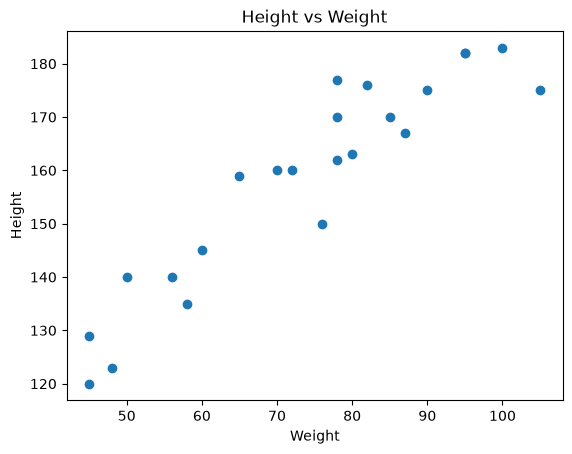

In [ ]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')

## Divide our dataste into Independent and Dependent Features

In [ ]:
X = df[['Weight']] # Independent Feature
y = df['Height'] # Dependent Feature

## Train Test Split


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
X.shape, X_train.shape, X_test.shape

((23, 1), (17, 1), (6, 1))

## Apply Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Text(0.5, 1.0, 'Height vs Weight')

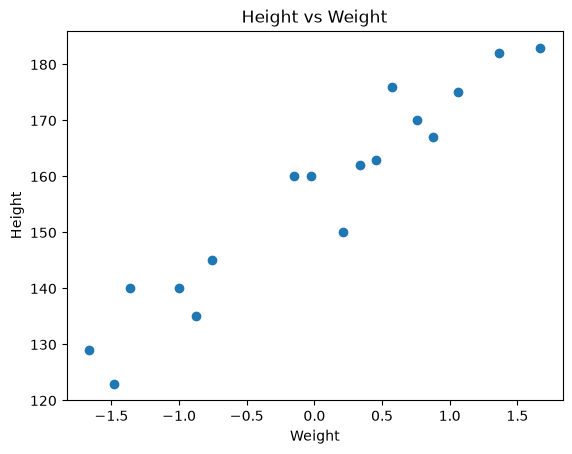

In [ ]:
plt.scatter(X_train, y_train)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')

## Train the Model

In [ ]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [ ]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [ ]:
print("The Slope or coefficient of weight is : ", regression.coef_)
print("The intercept : ", regression.intercept_)

The Slope or coefficient of weight is :  [17.2982057]
The intercept :  156.47058823529412


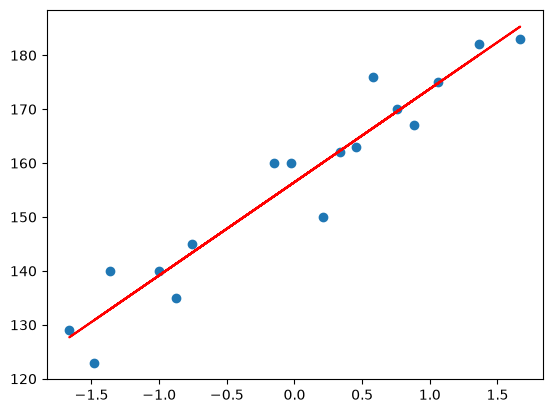

In [ ]:
plt.scatter(X_train, y_train)
y_pred = regression.predict(X_train)
plt.plot(X_train, y_pred, 'red')

In [ ]:
y_pred_test = regression.predict(X_test)
y_pred_test, y_test

(array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
        148.64197186, 190.55897293]),
 15    177
 9     170
 0     120
 8     182
 17    159
 12    175
 Name: Height, dtype: int64)

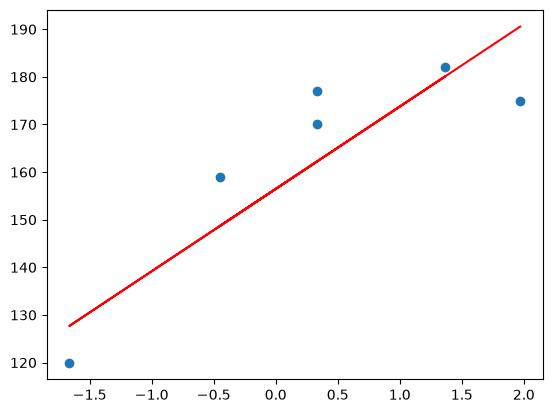

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_test, 'red')

## Test The Accuaracy with Performance Metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)

print("r2_score : ", score)

r2_score :  0.7360826717981276


## Adjusted R Square

**Formula:**
$$\text{Adjusted R}^2 = 1 - \left[\frac{(1-R^2)(n-1)}{(n-k-1)}\right]$$

**Where:**
- **R²**: The R² of the model
- **n**: The number of observations
- **k**: The number of predictor variables

In [ ]:
adjr2 = 1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [ ]:
print("Adjusted R2 : ", adjr2)

Adjusted R2 :  0.6701033397476595


## How will you know you have train your model very well

In [ ]:
# Let test with new data points
scaled_weight = scaler.transform([[80]]) # This is a new user input weight
scaled_weight # converted to standard value

c:\Users\sagarnai\OneDrive - Capgemini\Desktop\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.45613165]])

In [ ]:
print(regression.predict(scaled_weight))

[164.36084726]


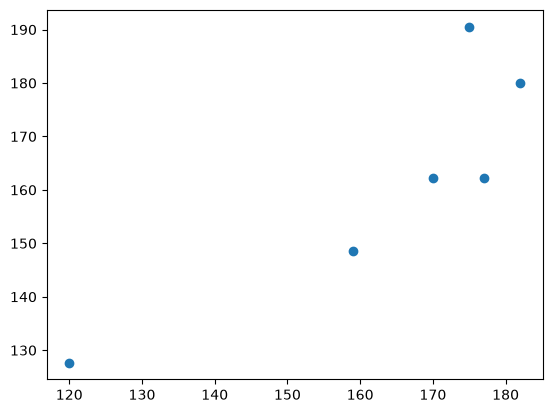

In [ ]:
### Assumption Required in Simple linear regression

plt.scatter(y_test, y_pred_test)
# You will get a linear scatter data points

In [ ]:
# Residuals : differnce between y_test and y_pred_test
residuals = y_test-y_pred_test
residuals

15    14.735003
9      7.735003
0     -7.683471
8      1.920277
17    10.358028
12   -15.558973
Name: Height, dtype: float64

C:\Users\sagarnai\AppData\Local\Temp\ipykernel_44812\648249810.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

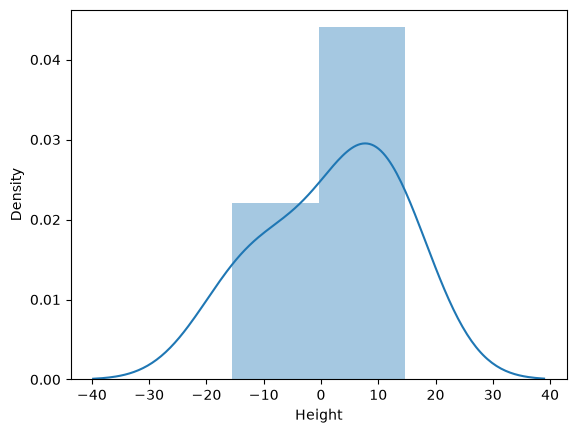

In [ ]:
import seaborn as sns
sns.distplot(residuals, kde=True)
# Yes we get a normal distribution , still there is left skew but it's quite noirmally distributed so we can say our model is better

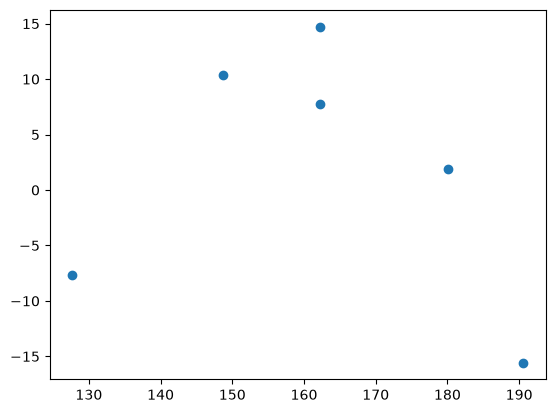

In [ ]:
#  Sactter plot with respect to prediction and residuals ---. it should result in uniform distribution
plt.scatter(y_pred_test, residuals)